In [1]:
import pandas as pd

path = r"E:/Midaharsyad/Upgrade Skill/Rakamin_Data Scientist_Home Kredit/Week 4/Project/Dataset/application_train.csv"

df = pd.read_csv(
    path,
    sep=";",
    engine="python",
    on_bad_lines="skip",
    encoding="latin1"
)

print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(307511, 122)


In [3]:
# Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(62), int64(41), object(19)
memory usage: 286.2+ MB


In [5]:
# Data Understanding
y = df["TARGET"]
train = df.drop("TARGET", axis=1)

print(train.shape)
print(y.shape)

(307511, 121)
(307511,)


In [7]:
# Data Cleaning
# Cek Missing value
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64

In [9]:
# Data Cleaning
# Drop Missing value
missing = train.isnull().mean().sort_values(ascending=False) * 100
missing[missing > 0]

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64

In [11]:
# Data Cleaning
# Drop Missing value
missing_ratio = train.isnull().mean()

drop_cols = missing_ratio[missing_ratio > 0.65].index

train = train.drop(columns=drop_cols)

print("Jumlah kolom setelah drop:", train.shape)
print("Kolom yang dihapus:", len(drop_cols))

Jumlah kolom setelah drop: (307511, 104)
Kolom yang dihapus: 17


In [13]:
# Data Cleaning
# Handling Missing value
# pisahkan tipe data
num_cols = train.select_dtypes(include=['int64','float64']).columns
cat_cols = train.select_dtypes(include=['object']).columns

# simpan median & mode
num_median = train[num_cols].median()
cat_mode = train[cat_cols].mode().iloc[0]

# isi missing
train[num_cols] = train[num_cols].fillna(num_median)
train[cat_cols] = train[cat_cols].fillna(cat_mode)

print("Sisa missing:", train.isnull().sum().sum())

Sisa missing: 0


In [15]:
# Data Cleaning
# Cek Duplikat
train.duplicated().sum()

0

In [17]:
# Data Cleaning
# Drop kolom tidak diperlukan
# Drop ID
train = train.drop(columns=["SK_ID_CURR"], errors="ignore")

# Drop FLAG_DOCUMENT columns
doc_cols = [col for col in train.columns if "FLAG_DOCUMENT" in col]
train = train.drop(columns=doc_cols)

print("Jumlah kolom sekarang:", train.shape[1])

Jumlah kolom sekarang: 83


In [19]:
# Data Cleaning
# Cek tipe data
cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, df[col].unique()[:10])

NAME_CONTRACT_TYPE ['Cash loans' 'Revolving loans']
CODE_GENDER ['M' 'F' 'XNA']
FLAG_OWN_CAR ['N' 'Y']
FLAG_OWN_REALTY ['Y' 'N']
AMT_INCOME_TOTAL ['202500.0' '270000.0' '67500.0' '135000.0' '121500.0' '99000.0'
 '171000.0' '360000.0' '112500.0' '38.419.155']
NAME_TYPE_SUITE ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']
NAME_INCOME_TYPE ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
NAME_EDUCATION_TYPE ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']
NAME_HOUSING_TYPE ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment']
DAYS_REGISTRATION ['-3648.0' '-1186.0' '-4260.0' '-9833.0' '-4311.0' '-4970.0' '-1213.0'
 '-4597.0' '-7427.0' '-14437.0']
OC

In [21]:
# Data Cleaning
# replace data XNA
import numpy as np

replace_dict = {
    "CODE_GENDER": "XNA",
    "NAME_FAMILY_STATUS": "Unknown",
    "ORGANIZATION_TYPE": "XNA"
}

for col, bad_val in replace_dict.items():
    train[col] = train[col].replace(bad_val, np.nan)
    train[col] = train[col].fillna(train[col].mode()[0])

print(
    train[["CODE_GENDER","NAME_FAMILY_STATUS","ORGANIZATION_TYPE"]]
    .isin(["XNA","Unknown"])
    .sum()
)

CODE_GENDER           0
NAME_FAMILY_STATUS    0
ORGANIZATION_TYPE     0
dtype: int64


In [23]:
# Data Cleaning
# Cek nama kolom
print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

In [25]:
# Data Cleaning
# ganti type data
train["AMT_INCOME_TOTAL"] = (train["AMT_INCOME_TOTAL"] .astype(str) .str.replace(".", "", regex=False) .astype(float) )

In [27]:
train["AMT_INCOME_TOTAL"].dtype

dtype('float64')

In [29]:
# Data Cleaning
# Cek Ourlier
import matplotlib.pyplot as plt

num_cols = train.select_dtypes(include=['int64','float64']).columns

cols_with_outliers = []

for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    if ((train[col] < lower) | (train[col] > upper)).any():
        cols_with_outliers.append(col)

print("Kolom yang punya outlier:", cols_with_outliers)

Kolom yang punya outlier: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTR

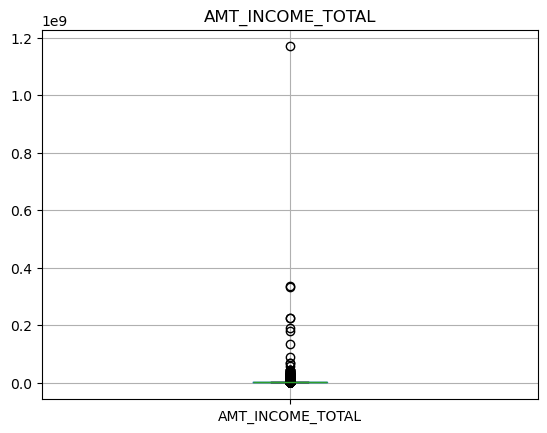

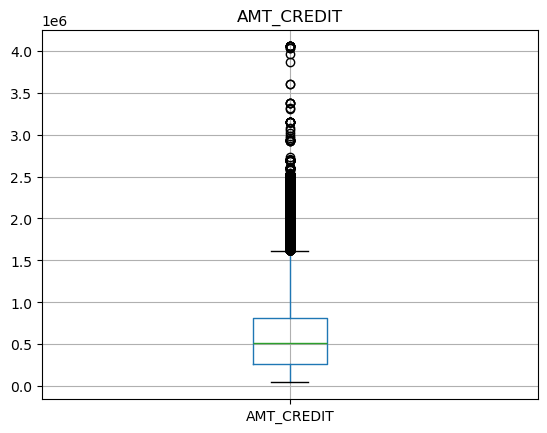

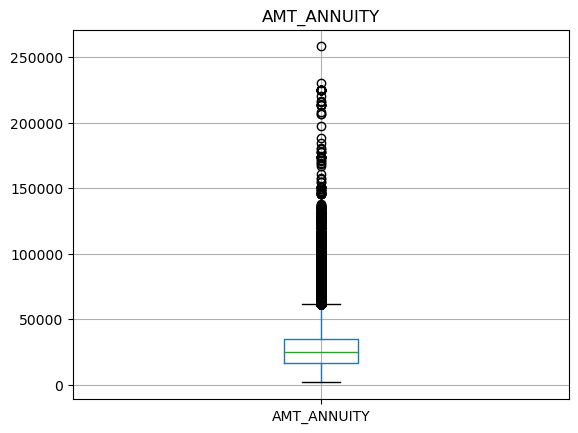

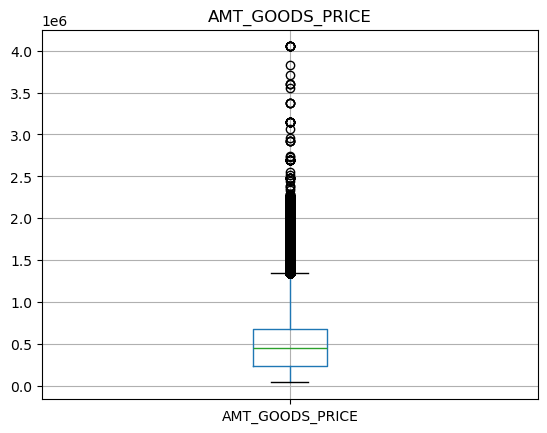

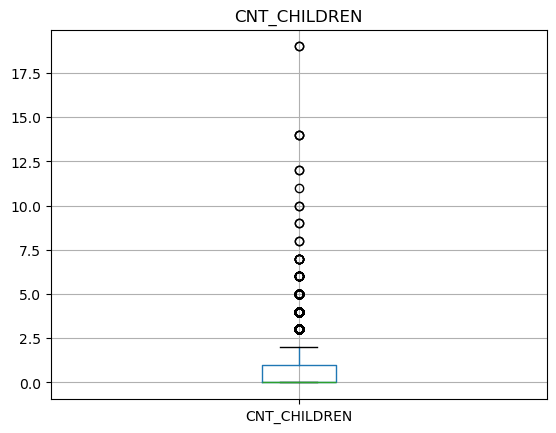

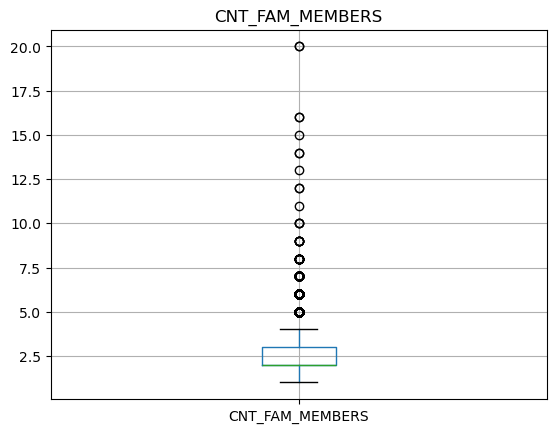

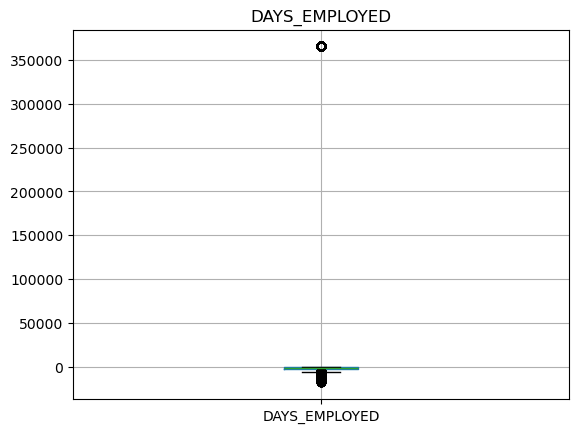

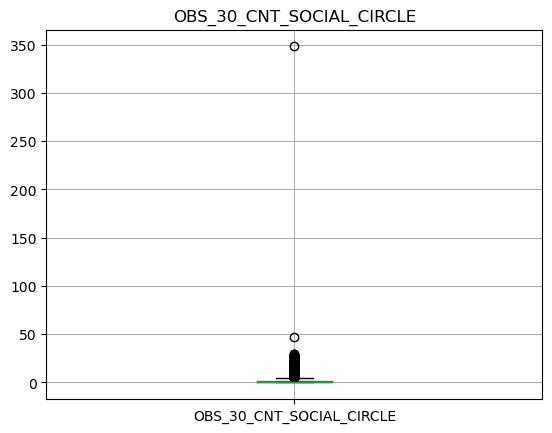

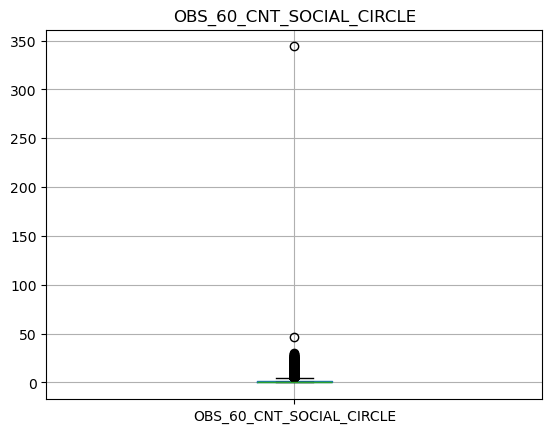

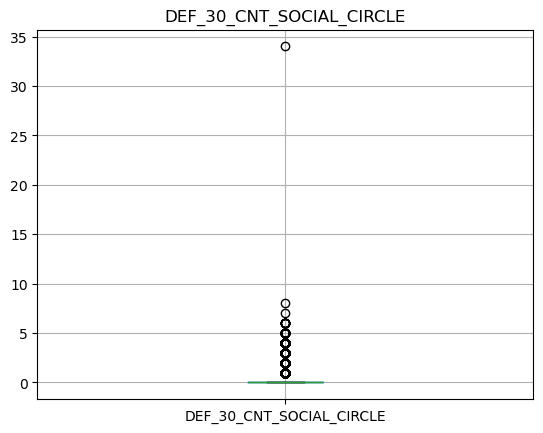

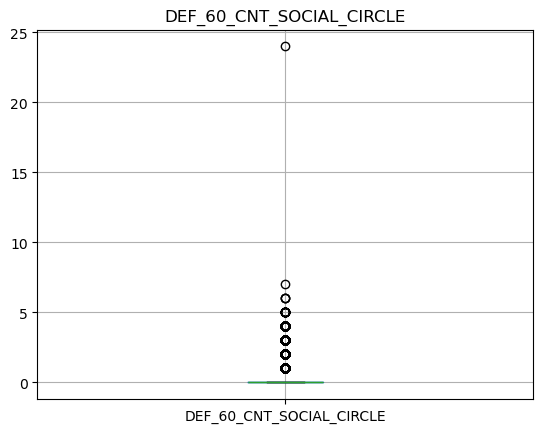

In [31]:
# Data Cleaning
# Cek Ourlier
# visualisasi Ourlier
import matplotlib.pyplot as plt

num_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "DAYS_EMPLOYED", "OBS_30_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]

for col in num_cols:
    plt.figure()
    train.boxplot(column=col)
    plt.title(col)
    plt.show()

In [33]:
# Data Cleaning
# Handling Outlier
import numpy as np

# log transform
log_cols = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE"]

for col in log_cols:
    if col in train.columns:
        train[col] = np.log1p(train[col])

# clip
train["CNT_CHILDREN"] = train["CNT_CHILDREN"].clip(upper=5)
train["CNT_FAM_MEMBERS"] = train["CNT_FAM_MEMBERS"].clip(upper=7)

# replace nilai error
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)

# isi lagi NaN yang muncul
train["DAYS_EMPLOYED"] = train["DAYS_EMPLOYED"].fillna(train["DAYS_EMPLOYED"].median())

In [35]:
# Data Cleaning
# Handling Outlier
print(train.isnull().sum().sum())

0


In [37]:
# Data Cleaning
# Handling Outlier
train.describe().T

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.0,0.416616,0.717272,0.000000,0.000000,0.000000,1.000000,5.000000
AMT_INCOME_TOTAL,307511.0,14.212138,0.489856,12.454888,13.933294,14.205974,14.521081,20.880270
AMT_CREDIT,307511.0,13.070108,0.715193,10.714440,12.506181,13.149068,13.603123,15.214228
AMT_ANNUITY,307511.0,10.067677,0.545872,7.388019,9.712630,10.122784,10.451522,12.460818
AMT_GOODS_PRICE,307511.0,12.960539,0.715197,10.609082,12.382129,13.017005,13.429114,15.214228
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,307511.0,0.006055,0.103037,0.000000,0.000000,0.000000,0.000000,9.000000
AMT_REQ_CREDIT_BUREAU_WEEK,307511.0,0.029723,0.190728,0.000000,0.000000,0.000000,0.000000,8.000000
AMT_REQ_CREDIT_BUREAU_MON,307511.0,0.231293,0.856810,0.000000,0.000000,0.000000,0.000000,27.000000
AMT_REQ_CREDIT_BUREAU_QRT,307511.0,0.229631,0.744059,0.000000,0.000000,0.000000,0.000000,261.000000


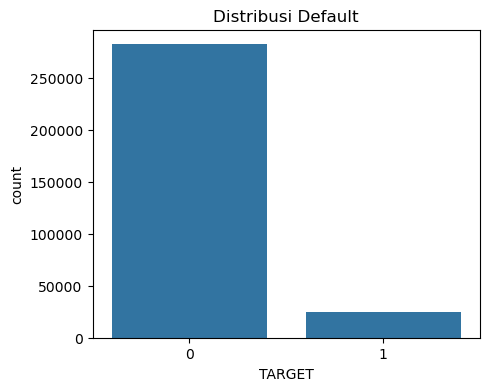

Default rate: 8.072881945686495 %


In [39]:
# Exploratory Data Analysis
# Target Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Distribusi Default")
plt.show()

print("Default rate:", y.mean()*100, "%")

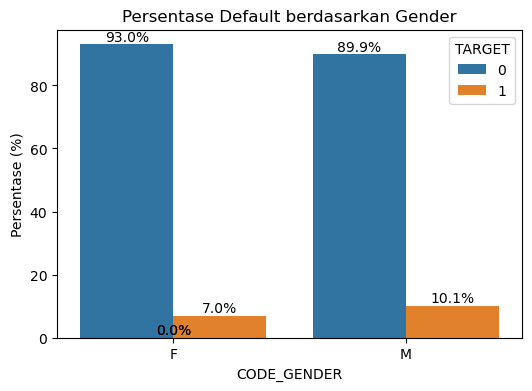

In [41]:
# Exploratory Data Analysis
# Demografi vs Resiko
# Gender vs Default
import seaborn as sns
import matplotlib.pyplot as plt

# gabungkan sementara untuk EDA
eda_df = train.copy()
eda_df["TARGET"] = y

gender_target = (
    eda_df.groupby("CODE_GENDER")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))
ax = sns.barplot(x="CODE_GENDER", y="percent", hue="TARGET", data=gender_target)

plt.title("Persentase Default berdasarkan Gender")
plt.ylabel("Persentase (%)")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom')

plt.show()

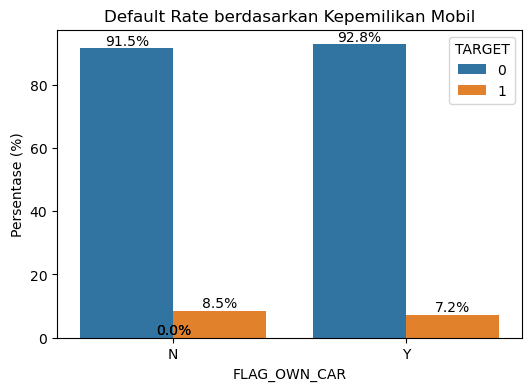

In [43]:
# Exploratory Data Analysis
# Demografi vs Resiko
# Kepemilikan mobil vs default
# gabungkan sementara untuk EDA
eda_df = train.copy()
eda_df["TARGET"] = y

car_target = (
    eda_df.groupby("FLAG_OWN_CAR")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))
ax = sns.barplot(x="FLAG_OWN_CAR", y="percent", hue="TARGET", data=car_target)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Default Rate berdasarkan Kepemilikan Mobil")
plt.ylabel("Persentase (%)")
plt.show()

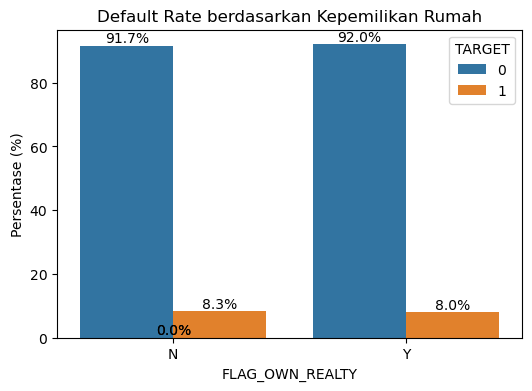

In [45]:
# Exploratory Data Analysis
# Demografi vs Resiko
# Kepemilikan rumah vs default
eda_df = train.copy()
eda_df["TARGET"] = y

house_target = (
    eda_df.groupby("FLAG_OWN_REALTY")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(6,4))
ax = sns.barplot(x="FLAG_OWN_REALTY", y="percent", hue="TARGET", data=house_target)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Default Rate berdasarkan Kepemilikan Rumah")
plt.ylabel("Persentase (%)")
plt.show()

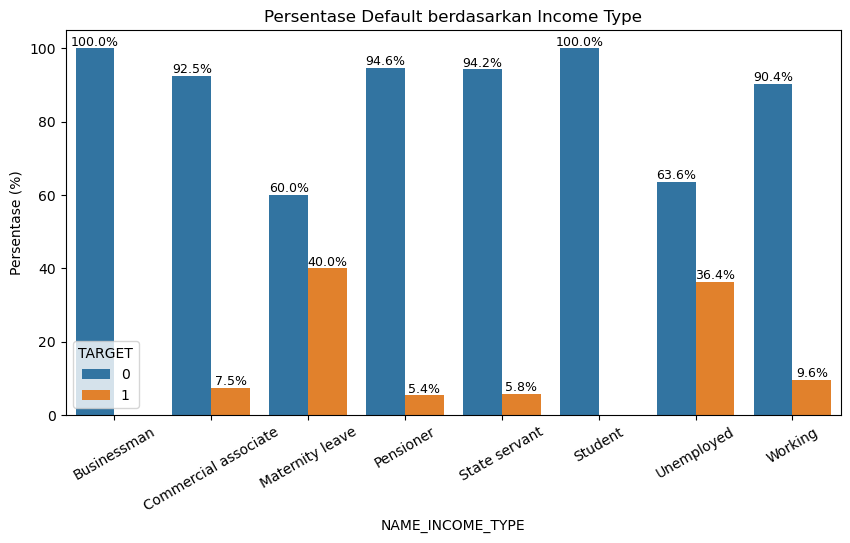

In [47]:
# Exploratory Data Analysis
# Demografi vs Resiko
# Income type vs default
# gabungkan sementara untuk EDA
eda_df = train.copy()
eda_df["TARGET"] = y

income_target = (
    eda_df.groupby("NAME_INCOME_TYPE")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    x="NAME_INCOME_TYPE",
    y="percent",
    hue="TARGET",
    data=income_target
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=9)

plt.title("Persentase Default berdasarkan Income Type")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=30)
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_19240\3668807156.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("INCOME_BIN")["TARGET"]


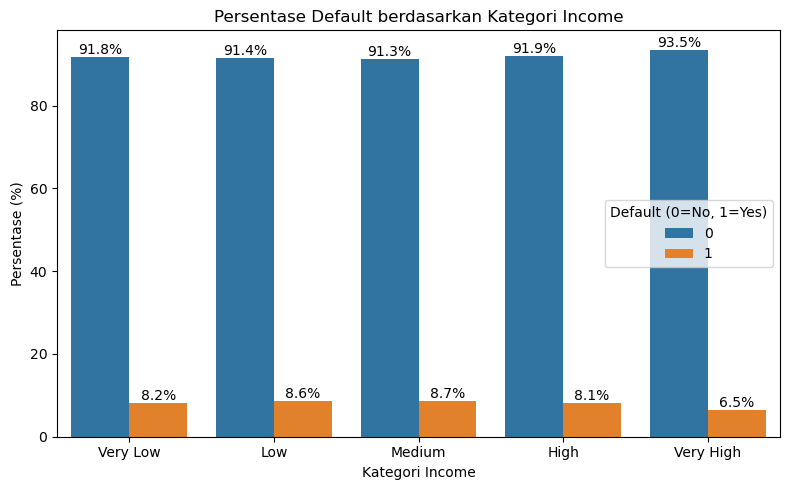

In [49]:
# Exploratory Data Analysis
# Financial Risk Analysis
# Income vs default
eda_df = train.copy()
eda_df["TARGET"] = y

# Buat kategori income
eda_df["INCOME_BIN"] = pd.qcut(
    eda_df["AMT_INCOME_TOTAL"],
    5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

# Hitung persentase default per kategori income
income_target = (
    eda_df.groupby("INCOME_BIN")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# Visualisasi
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="INCOME_BIN",
    y="percent",
    hue="TARGET",
    data=income_target
)

# Tambahkan label persentase di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Kategori Income")
plt.ylabel("Persentase (%)")
plt.xlabel("Kategori Income")
plt.legend(title="Default (0=No, 1=Yes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_19240\2671107051.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("CREDIT_BIN")["TARGET"]


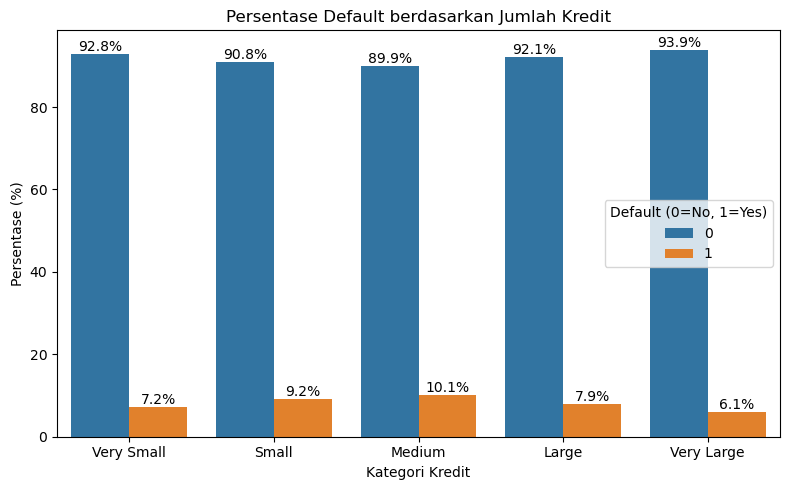

In [51]:
# Exploratory Data Analysis
# Financial Risk Analysis
# Credit Amount vs default

eda_df = train.copy()
eda_df["TARGET"] = y

# Buat kategori credit 
eda_df["CREDIT_BIN"] = pd.qcut(
    eda_df["AMT_CREDIT"],
    5,
    labels=["Very Small", "Small", "Medium", "Large", "Very Large"],
    duplicates="drop"
)

# Hitung persentase default tiap kategori
credit_target = (
    eda_df.groupby("CREDIT_BIN")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# Visualisasi
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x="CREDIT_BIN",
    y="percent",
    hue="TARGET",
    data=credit_target
)

# Tambahkan label persentase
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Jumlah Kredit")
plt.ylabel("Persentase (%)")
plt.xlabel("Kategori Kredit")
plt.legend(title="Default (0=No, 1=Yes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_19240\3564481658.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("ANNUITY_BIN")["TARGET"]


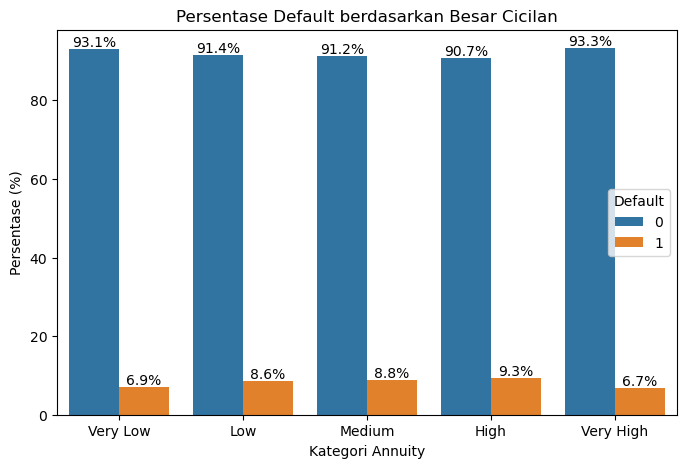

In [53]:
# Exploratory Data Analysis
# Financial Risk Analysis
# Annuity vs default

eda_df = train.copy()
eda_df["TARGET"] = y

eda_df["ANNUITY_BIN"] = pd.qcut(
    eda_df["AMT_ANNUITY"],
    5,
    labels=["Very Low","Low","Medium","High","Very High"]
)

# hitung persentase
annuity_target = (
    eda_df.groupby("ANNUITY_BIN")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# plot
plt.figure(figsize=(8,5))
ax = sns.barplot(x="ANNUITY_BIN", y="percent", hue="TARGET", data=annuity_target)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Besar Cicilan")
plt.ylabel("Persentase (%)")
plt.xlabel("Kategori Annuity")
plt.legend(title="Default")
plt.show()

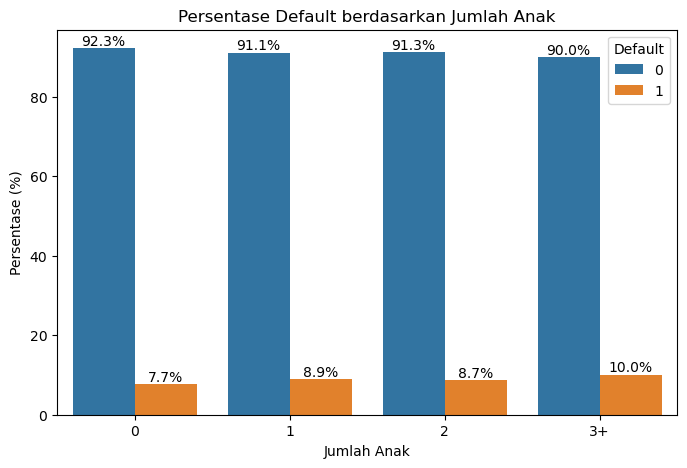

In [55]:
# Exploratory Data Analysis
# Tanggungan vs default
# Children vs default

eda_df = train.copy()
eda_df["TARGET"] = y

# kategori jumlah anak
def child_group(x):
    if x == 0:
        return "0"
    elif x == 1:
        return "1"
    elif x == 2:
        return "2"
    else:
        return "3+"

eda_df["CHILD_GROUP"] = eda_df["CNT_CHILDREN"].apply(child_group)

# hitung persentase
child_target = (
    eda_df.groupby("CHILD_GROUP")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# plot
plt.figure(figsize=(8,5))
ax = sns.barplot(x="CHILD_GROUP", y="percent", hue="TARGET", data=child_target)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Jumlah Anak")
plt.ylabel("Persentase (%)")
plt.xlabel("Jumlah Anak")
plt.legend(title="Default")
plt.show()

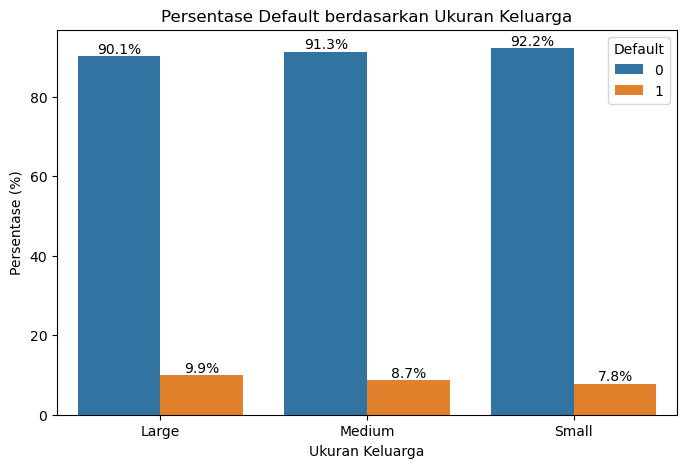

In [57]:
# Exploratory Data Analysis
# Tanggungan vs default
# family size vs default

eda_df = train.copy()
eda_df["TARGET"] = y
# kategori ukuran keluarga
def fam_group(x):
    if x <= 2:
        return "Small"
    elif x <= 4:
        return "Medium"
    else:
        return "Large"

eda_df["FAM_GROUP"] = eda_df["CNT_FAM_MEMBERS"].apply(fam_group)

# hitung persentase
fam_target = (
    eda_df.groupby("FAM_GROUP")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# plot
plt.figure(figsize=(8,5))
ax = sns.barplot(x="FAM_GROUP", y="percent", hue="TARGET", data=fam_target)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Ukuran Keluarga")
plt.ylabel("Persentase (%)")
plt.xlabel("Ukuran Keluarga")
plt.legend(title="Default")
plt.show()


C:\Users\khami\AppData\Local\Temp\ipykernel_19240\1474670580.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("EMP_GROUP")["TARGET"]


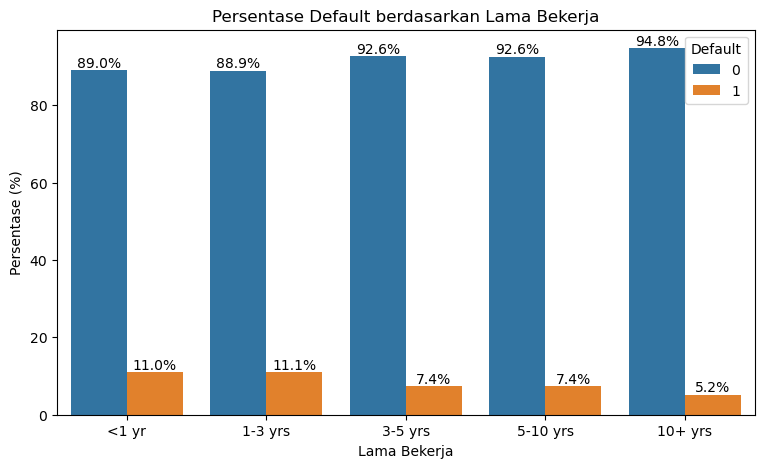

In [59]:
# Exploratory Data Analysis
# Behavior Pattern
# employment length vs default

eda_df = train.copy()
eda_df["TARGET"] = y
# ubah hari jadi tahun
eda_df["EMPLOY_YEARS"] = abs(eda_df["DAYS_EMPLOYED"]) / 365

# kategori lama kerja
def emp_group(x):
    if x < 1:
        return "<1 yr"
    elif x < 3:
        return "1-3 yrs"
    elif x < 5:
        return "3-5 yrs"
    elif x < 10:
        return "5-10 yrs"
    else:
        return "10+ yrs"

eda_df["EMP_GROUP"] = eda_df["EMPLOY_YEARS"].apply(emp_group)
order_emp = ["<1 yr", "1-3 yrs", "3-5 yrs", "5-10 yrs", "10+ yrs"]
eda_df["EMP_GROUP"] = pd.Categorical(eda_df["EMP_GROUP"], categories=order_emp, ordered=True)

# hitung persentase
emp_target = (
    eda_df.groupby("EMP_GROUP")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# plot
plt.figure(figsize=(9,5))
ax = sns.barplot(x="EMP_GROUP", y="percent", hue="TARGET", data=emp_target)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Lama Bekerja")
plt.xlabel("Lama Bekerja")
plt.ylabel("Persentase (%)")
plt.legend(title="Default")
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_19240\1364186949.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("PHONE_GROUP")["TARGET"]


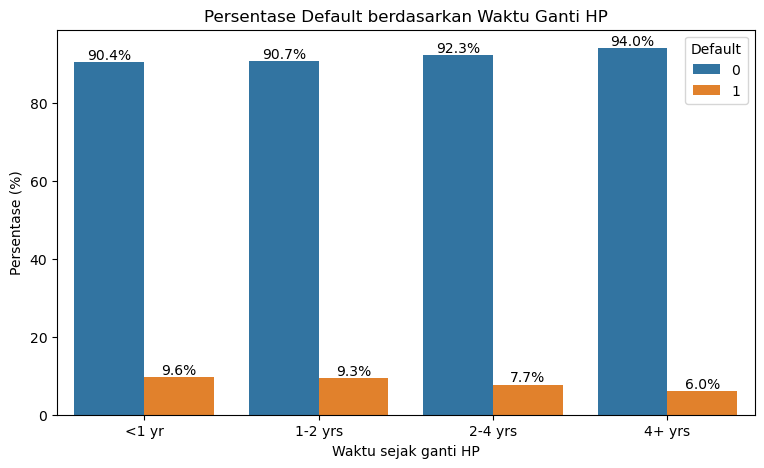

In [61]:
# Exploratory Data Analysis
# Behavior Pattern
# last phone change vs default

eda_df = train.copy()
eda_df["TARGET"] = y
# ubah ke tahun
eda_df["PHONE_CHANGE_YEARS"] = abs(eda_df["DAYS_LAST_PHONE_CHANGE"]) / 365

# kategori
def phone_group(x):
    if x < 1:
        return "<1 yr"
    elif x < 2:
        return "1-2 yrs"
    elif x < 4:
        return "2-4 yrs"
    else:
        return "4+ yrs"

eda_df["PHONE_GROUP"] = eda_df["PHONE_CHANGE_YEARS"].apply(phone_group)
order_emp = ["<1 yr", "1-2 yrs", "2-4 yrs", "4+ yrs"]
eda_df["PHONE_GROUP"] = pd.Categorical(eda_df["PHONE_GROUP"], categories=order_emp, ordered=True)

# hitung persentase
phone_target = (
    eda_df.groupby("PHONE_GROUP")["TARGET"]
    .value_counts(normalize=True)
    .rename("percent")
    .mul(100)
    .reset_index()
)

# plot
plt.figure(figsize=(9,5))
ax = sns.barplot(x="PHONE_GROUP", y="percent", hue="TARGET", data=phone_target)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Persentase Default berdasarkan Waktu Ganti HP")
plt.xlabel("Waktu sejak ganti HP")
plt.ylabel("Persentase (%)")
plt.legend(title="Default")
plt.show()


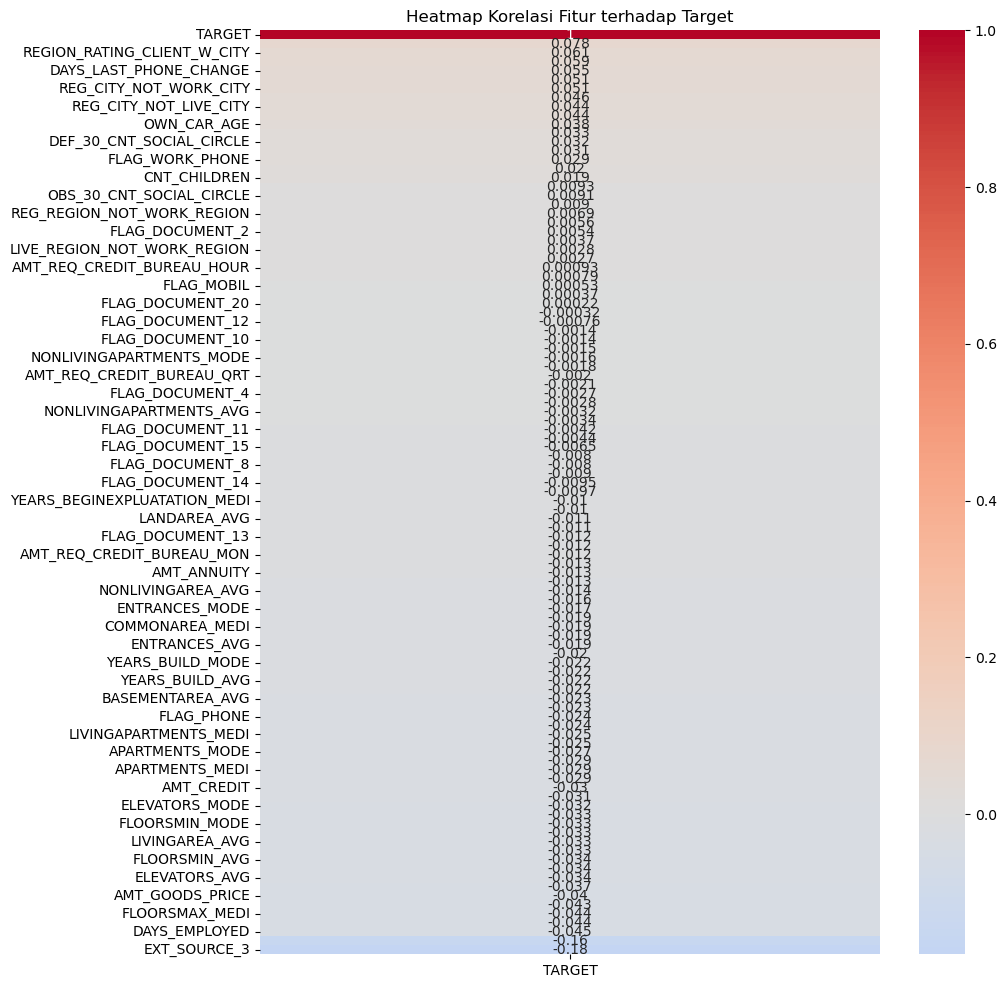

In [63]:
# Exploratory Data Analysis
# Feature Importance Awal (Korelasi)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,12))
sns.heatmap(
    corr[["TARGET"]].sort_values(by="TARGET", ascending=False),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Heatmap Korelasi Fitur terhadap Target")
plt.show()

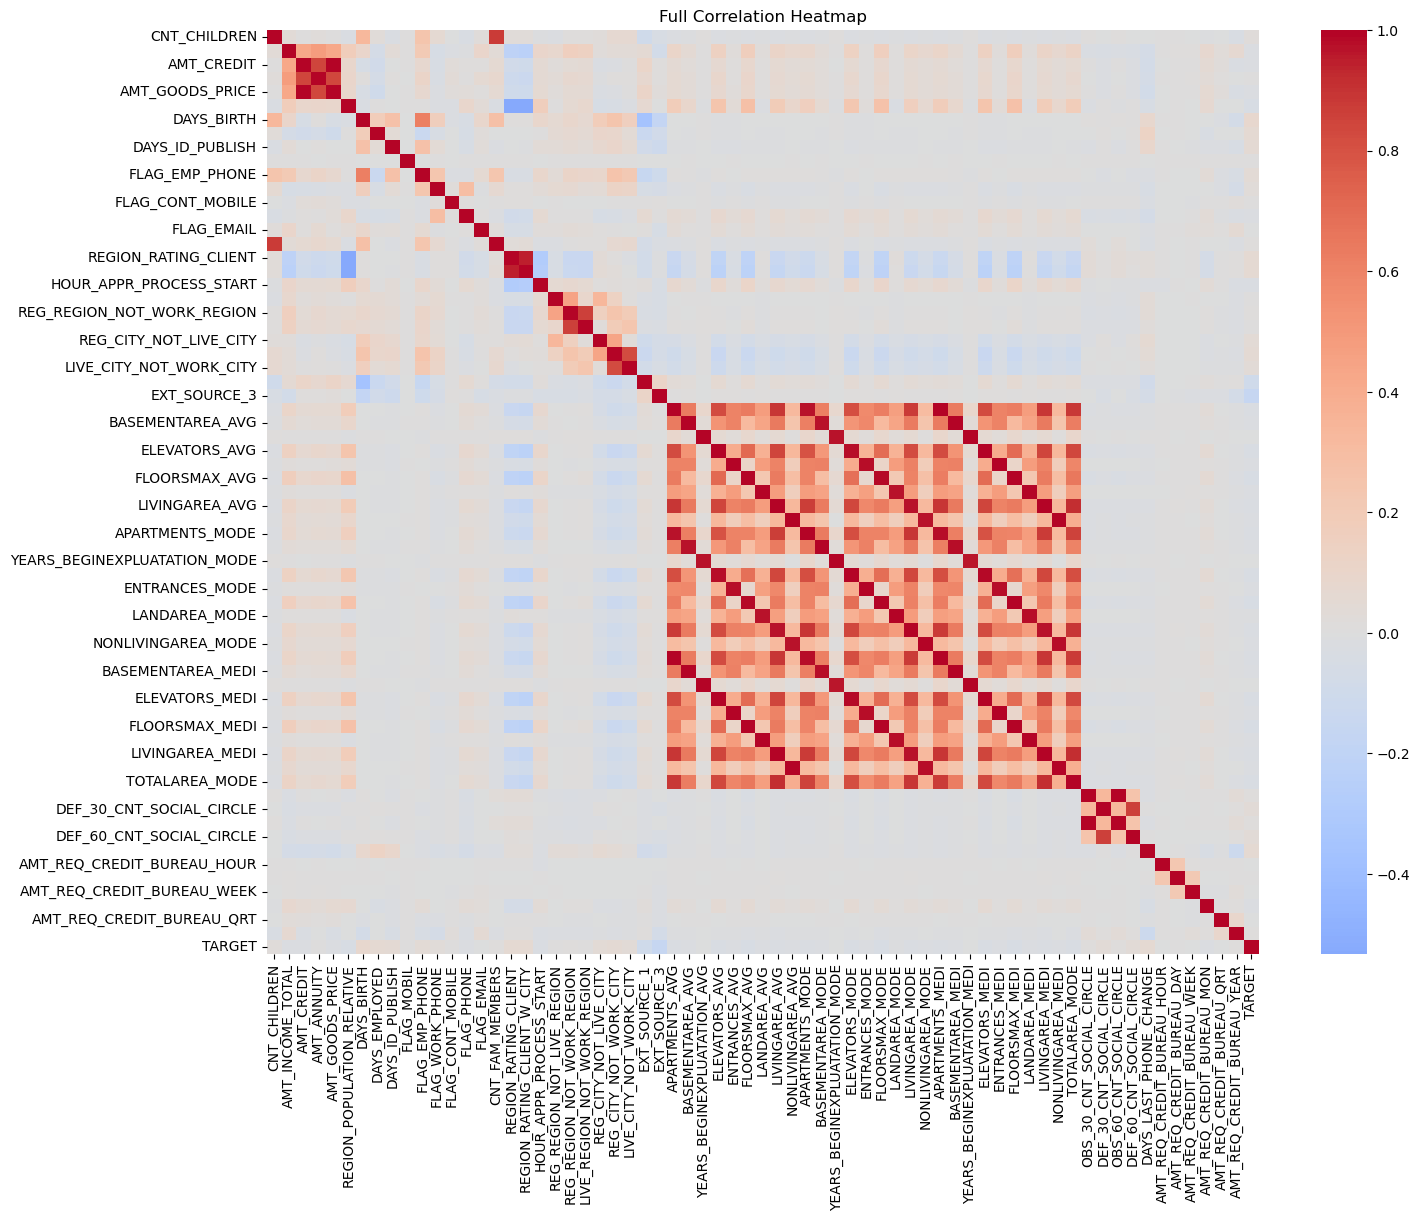

In [65]:
# Exploratory Data Analysis
# Feature Importance Awal (Korelasi)

eda_df = train.copy()
eda_df["TARGET"] = y

# Hitung korelasi numerik saja
corr = eda_df.corr(numeric_only=True)

# Visualisasi heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Full Correlation Heatmap")
plt.show()

In [67]:
import numpy as np
import pandas as pd

eda_df = train.copy()
eda_df["TARGET"] = y

corr = eda_df.corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Kolom yang sangat berkorelasi:", high_corr)

Kolom yang sangat berkorelasi: ['AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAREA_MEDI', 'OBS_60_CNT_SOCIAL_CIRCLE']


In [69]:
corr = df.corr(numeric_only=True).abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(high_corr)

DAYS_EMPLOYED                 FLAG_EMP_PHONE                0.999755
YEARS_BUILD_AVG               YEARS_BUILD_MEDI              0.998495
OBS_30_CNT_SOCIAL_CIRCLE      OBS_60_CNT_SOCIAL_CIRCLE      0.998490
FLOORSMIN_AVG                 FLOORSMIN_MEDI                0.997241
FLOORSMAX_AVG                 FLOORSMAX_MEDI                0.997034
                                                              ...   
ENTRANCES_MEDI                AMT_REQ_CREDIT_BUREAU_QRT     0.000008
YEARS_BEGINEXPLUATATION_AVG   FLAG_DOCUMENT_4               0.000007
YEARS_BEGINEXPLUATATION_MODE  FLAG_DOCUMENT_4               0.000005
FLAG_MOBIL                    FLAG_DOCUMENT_12              0.000005
BASEMENTAREA_MODE             AMT_REQ_CREDIT_BUREAU_HOUR    0.000004
Length: 5219, dtype: float64


In [71]:
corr = df.corr(numeric_only=True).abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(high_corr.head(10))

DAYS_EMPLOYED             FLAG_EMP_PHONE              0.999755
YEARS_BUILD_AVG           YEARS_BUILD_MEDI            0.998495
OBS_30_CNT_SOCIAL_CIRCLE  OBS_60_CNT_SOCIAL_CIRCLE    0.998490
FLOORSMIN_AVG             FLOORSMIN_MEDI              0.997241
FLOORSMAX_AVG             FLOORSMAX_MEDI              0.997034
ENTRANCES_AVG             ENTRANCES_MEDI              0.996886
ELEVATORS_AVG             ELEVATORS_MEDI              0.996099
COMMONAREA_AVG            COMMONAREA_MEDI             0.995978
LIVINGAREA_AVG            LIVINGAREA_MEDI             0.995596
APARTMENTS_AVG            APARTMENTS_MEDI             0.995081
dtype: float64


In [73]:
# Feature Engineering
# Feature Selection
# Drop fitur redundant

drop_cols = [
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "FLOORSMAX_MEDI",
    "ENTRANCES_MEDI",
    "ELEVATORS_MEDI",
    "LIVINGAREA_MEDI",
    "APARTMENTS_MEDI",
    "BASEMENTAREA_MEDI",
    "YEARS_BEGINEXPLUATATION_MEDI",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_EMPLOYED"
]

train = train.drop(columns=[col for col in drop_cols if col in train.columns])

print("Jumlah kolom setelah feature selection:", train.shape[1])

Jumlah kolom setelah feature selection: 73


In [75]:
# Feature Engineering
# encoding
cat_cols = train.select_dtypes(include="object").columns
print(cat_cols)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_REGISTRATION',
       'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EXT_SOURCE_2', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
       'EMERGENCYSTATE_MODE'],
      dtype='object')


In [77]:
# Feature Engineering
# encoding
for col in cat_cols:
    print(col, df[col].nunique())

NAME_CONTRACT_TYPE 2
CODE_GENDER 3
FLAG_OWN_CAR 2
FLAG_OWN_REALTY 2
NAME_TYPE_SUITE 7
NAME_INCOME_TYPE 8
NAME_EDUCATION_TYPE 5
NAME_FAMILY_STATUS 6
NAME_HOUSING_TYPE 6
DAYS_REGISTRATION 15688
OCCUPATION_TYPE 18
WEEKDAY_APPR_PROCESS_START 7
ORGANIZATION_TYPE 58
EXT_SOURCE_2 119829
HOUSETYPE_MODE 3
WALLSMATERIAL_MODE 7
EMERGENCYSTATE_MODE 2


In [79]:
# Feature Engineering
# encoding
# FIX FORMAT ANGKA ANEH
train["DAYS_REGISTRATION"] = (
    train["DAYS_REGISTRATION"]
    .astype(str)
    .str.replace(".", "", regex=False)
)

train["DAYS_REGISTRATION"] = pd.to_numeric(train["DAYS_REGISTRATION"], errors="coerce")


# EXT_SOURCE_2
train["EXT_SOURCE_2"] = pd.to_numeric(train["EXT_SOURCE_2"], errors="coerce")

In [81]:
print(df["DAYS_REGISTRATION"].dtype)
print(df["DAYS_REGISTRATION"].isnull().sum())

object
0


In [83]:
# Feature Engineering
# Encoding

import pandas as pd
import numpy as np

# Fix Numeric yang masih object
# DAYS_REGISTRATION
if "DAYS_REGISTRATION" in train.columns:
    train["DAYS_REGISTRATION"] = (
        train["DAYS_REGISTRATION"]
        .astype(str)
        .str.replace(".", "", regex=False)
    )
    train["DAYS_REGISTRATION"] = pd.to_numeric(train["DAYS_REGISTRATION"], errors="coerce")

# EXT_SOURCE_2
if "EXT_SOURCE_2" in train.columns:
    train["EXT_SOURCE_2"] = pd.to_numeric(train["EXT_SOURCE_2"], errors="coerce")


# Binary Encoding
binary_map = {
    "NAME_CONTRACT_TYPE": {"Cash loans":0, "Revolving loans":1},
    "CODE_GENDER": {"M":1, "F":0},
    "FLAG_OWN_CAR": {"Y":1, "N":0},
    "FLAG_OWN_REALTY": {"Y":1, "N":0},
    "EMERGENCYSTATE_MODE": {"Yes":1, "No":0}
}

for col, mapping in binary_map.items():
    if col in train.columns:
        train[col] = train[col].map(mapping)

# One Hot Encoding

onehot_cols = train.select_dtypes(include="object").columns

train = pd.get_dummies(train, columns=onehot_cols, drop_first=True)

print("Jumlah kolom setelah encoding:", train.shape[1])
print("Sisa kolom object:", train.select_dtypes(include="object").columns)
print("Masih ada NaN:", train.isnull().sum().sum())

Jumlah kolom setelah encoding: 176
Sisa kolom object: Index([], dtype='object')
Masih ada NaN: 43


In [85]:
nan_cols = train.columns[train.isnull().sum() > 0]
print(train[nan_cols].isnull().sum())

EXT_SOURCE_2    43
dtype: int64


In [87]:
train["EXT_SOURCE_2"] = train["EXT_SOURCE_2"].fillna(train["EXT_SOURCE_2"].median())

print("Sisa NaN:", train.isnull().sum().sum())

Sisa NaN: 0


In [89]:
# Modelling
# Split data
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting kalau klasifikasi imbalance
)

print(X_train.shape)
print(X_val.shape)

(246008, 176)
(61503, 176)


In [91]:
print(X_train.dtypes.unique())

[dtype('int64') dtype('float64') dtype('bool')]


In [93]:
# Modelling
# Imbalance data
print(y_train.value_counts())
print((y_train.value_counts(normalize=True)*100).round(2))

TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [95]:
pip install imbalanced-learn

In [97]:
# Modelling
# Handling Imbalance data
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

C:\Users\khami\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [99]:
print(y_train_sm.value_counts())

TARGET
0    226148
1    226148
Name: count, dtype: int64


In [101]:
# Modelling
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(X_train_sm, y_train_sm)

y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     56538
           1       0.13      0.14      0.13      4965

    accuracy                           0.86     61503
   macro avg       0.53      0.53      0.53     61503
weighted avg       0.86      0.86      0.86     61503

ROC AUC: 0.578815620340295


In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_valid_scaled = scaler.transform(X_val)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(X_train_scaled, y_train_sm)

y_pred = model.predict(X_valid_scaled)
y_prob = model.predict_proba(X_valid_scaled)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.46      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.51      0.50     61503
weighted avg       0.88      0.92      0.88     61503

ROC AUC: 0.7116862146953398


In [109]:
# Modelling
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

dt_model.fit(X_train_sm, y_train_sm)

pred_dt = dt_model.predict(X_val)
proba_dt = dt_model.predict_proba(X_val)[:,1]

print("=== Decision Tree Result ===")
print(classification_report(y_val, pred_dt))

print("ROC AUC:", roc_auc_score(y_val, proba_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_val, pred_dt))

=== Decision Tree Result ===
              precision    recall  f1-score   support

           0       0.93      0.86      0.90     56538
           1       0.15      0.26      0.19      4965

    accuracy                           0.82     61503
   macro avg       0.54      0.56      0.54     61503
weighted avg       0.87      0.82      0.84     61503

ROC AUC: 0.6521228492617518
Confusion Matrix:
[[48883  7655]
 [ 3653  1312]]


In [111]:
# Modelling
# Random Forest + SMOTE


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)

proba = rf.predict_proba(X_val)[:,1]

print("\n===== THRESHOLD TEST =====")

for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]:

    pred = (proba >= t).astype(int)

    print("\n==============================")
    print("Threshold:", t)
    print("==============================")

    print(classification_report(y_val, pred))

    print("ROC AUC:", roc_auc_score(y_val, proba))

    print("Confusion Matrix:")
    print(confusion_matrix(y_val, pred))


# Feature Importance

feat_imp = pd.Series(rf.feature_importances_, index=X_train_sm.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("\n===== TOP 15 FEATURE IMPORTANCE =====")
print(feat_imp.head(15))


===== THRESHOLD TEST =====

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.26      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.59      0.51      0.49     61503
weighted avg       0.87      0.92      0.88     61503

ROC AUC: 0.7006196636207958
Confusion Matrix:
[[56330   208]
 [ 4893    72]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56538
           1       0.22      0.04      0.07      4965

    accuracy                           0.91     61503
   macro avg       0.57      0.52      0.51     61503
weighted avg       0.86      0.91      0.88     61503

ROC AUC: 0.7006196636207958
Confusion Matrix:
[[55768   770]
 [ 4747   218]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     56538
       

In [107]:
pip install xgboost

In [115]:
# Modelling
# xgboost

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Training XGBoost Model...")

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,   # karena sudah SMOTE
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    use_label_encoder=False
)


xgb.fit(X_train_sm, y_train_sm)

proba = xgb.predict_proba(X_val)[:,1]

print("\n===== THRESHOLD TEST =====")

for t in [0.5,0.4,0.3,0.25,0.2,0.15]:

    pred = (proba >= t).astype(int)

    print("\n==============================")
    print("Threshold:", t)
    print("==============================")

    print(classification_report(y_val, pred))

    print("ROC AUC:", roc_auc_score(y_val, proba))

    print("Confusion Matrix:")
    print(confusion_matrix(y_val, pred))



# Feature Importance

feat_imp = pd.Series(xgb.feature_importances_, index=X_train_sm.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("\n===== TOP 15 FEATURE IMPORTANCE =====")
print(feat_imp.head(15))

Training XGBoost Model...


C:\Users\khami\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:45:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== THRESHOLD TEST =====

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.49      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503

ROC AUC: 0.7343279321588806
Confusion Matrix:
[[56449    89]
 [ 4878    87]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.38      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.65      0.52      0.52     61503
weighted avg       0.88      0.92      0.89     61503

ROC AUC: 0.7343279321588806
Confusion Matrix:
[[56143   395]
 [ 4720   245]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     56538
       

In [117]:
# Modelling
# ExtraTreesClassifier

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

print("Training ExtraTrees Model...")

et_model = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=None,   # karena sudah SMOTE
    random_state=42,
    n_jobs=-1
)


et_model.fit(X_train_sm, y_train_sm)


proba = et_model.predict_proba(X_val)[:,1]

print("\n===== THRESHOLD TEST =====")

for t in [0.5,0.4,0.3,0.25,0.2,0.15]:

    pred = (proba >= t).astype(int)

    print("\n==============================")
    print("Threshold:", t)
    print("==============================")

    print(classification_report(y_val, pred))
    print("ROC AUC:", roc_auc_score(y_val, proba))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, pred))


# ============================
# Feature Importance
# ============================

feat_imp = pd.Series(et_model.feature_importances_, index=X_train_sm.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("\n===== TOP 15 FEATURE IMPORTANCE =====")
print(feat_imp.head(15))

Training ExtraTrees Model...

===== THRESHOLD TEST =====

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.27      0.01      0.01      4965

    accuracy                           0.92     61503
   macro avg       0.59      0.50      0.48     61503
weighted avg       0.87      0.92      0.88     61503

ROC AUC: 0.6973228033640415
Confusion Matrix:
[[56454    84]
 [ 4934    31]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.21      0.02      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.56      0.51      0.49     61503
weighted avg       0.86      0.92      0.88     61503

ROC AUC: 0.6973228033640415
Confusion Matrix:
[[56206   332]
 [ 4877    88]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.9